<a href="https://colab.research.google.com/github/SachinthaRashen/SLConsumerPriceAnalysis-DataScieneAssignment/blob/main/Data_Science_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load the data
df = pd.read_csv('sl_supermarket_data.csv')

print("Initial Dataset Head:")
print(df.head())
print(f"\nInitial Shape: {df.shape}")

Initial Dataset Head:
   Unnamed: 0         Supermarket Location    Rice_1kg   Sugar_1kg  \
0           0             Glomark  Colombo         NaN         NaN   
1           1        Laughs Super    Galle  212.706741  322.861318   
2           2             Sathosa  Colombo  243.894727  291.625903   
3           3             Glomark  Gampaha  213.490876  329.098556   
4           4  Arpico Supercentre    Kandy  209.009617  307.431877   

     Dhal_1kg  Milk_Powder_400g     Eggs_10  Chicken_1kg  \
0  301.222038       1075.751648  478.246816  1210.832199   
1  334.276778       1138.772274  607.204652  1066.524900   
2  329.375791        980.782166  580.042410  1402.365160   
3  354.035997       1027.943369  614.992548  1249.953553   
4  352.762263       1075.382449  624.306385  1253.608003   

   Vegetable_Assortment  Total_Basket_Cost Promo_Active  
0            650.064979        4622.849301           No  
1            590.833616        4547.880316           No  
2            423.06899

In [5]:
# 1. CLEANING & PREPROCESSING DATA
# Remove unnecessary columns (empty index column and extra promo column)
df = df.drop(columns=['Unnamed: 0', 'Promo_Active'])

In [6]:
# Standardize supermarket names
df['Supermarket'] = df['Supermarket'].str.strip() # Removes trailing spaces like in ' Keells '

In [7]:
# Replace messy user-entries with standard names
df['Supermarket'] = df['Supermarket'].replace({
    'cargills': 'Cargills Food City',
    'Arpico': 'Arpico Supercentre'
})

In [8]:
# Clean location names
df['Location'] = df['Location'].str.strip()

In [9]:
# Handle missing values (NA)
# For numeric columns, replace string 'NA' with actual pandas NA
numeric_cols = ['Rice_1kg', 'Sugar_1kg', 'Dhal_1kg', 'Milk_Powder_400g', 'Eggs_10', 'Chicken_1kg', 'Vegetable_Assortment', 'Total_Basket_Cost']
df[numeric_cols] = df[numeric_cols].replace('NA', pd.NA)

In [10]:
# Create a cleaned version of the dataset
cleaned_df = df.copy()

In [11]:
# Check for missing values
print("\nMissing values per column before filling:")
print(cleaned_df.isnull().sum())


Missing values per column before filling:
Supermarket              0
Location                 0
Rice_1kg                11
Sugar_1kg                7
Dhal_1kg                 0
Milk_Powder_400g         0
Eggs_10                  0
Chicken_1kg              0
Vegetable_Assortment     0
Total_Basket_Cost        0
dtype: int64


In [12]:
# Fill missing values with 0
cleaned_df.fillna(0, inplace=True)

In [13]:
# Check for missing values after filling
print("\nMissing values per column after filling:")
print(cleaned_df.isnull().sum())


Missing values per column after filling:
Supermarket             0
Location                0
Rice_1kg                0
Sugar_1kg               0
Dhal_1kg                0
Milk_Powder_400g        0
Eggs_10                 0
Chicken_1kg             0
Vegetable_Assortment    0
Total_Basket_Cost       0
dtype: int64


In [14]:
# Convert columns to numeric type
cleaned_df[numeric_cols] = cleaned_df[numeric_cols].apply(pd.to_numeric)

In [15]:
# Check for duplicates
print(f"\nDuplicate rows before dropping: {cleaned_df.duplicated().sum()}")
cleaned_df.drop_duplicates(inplace=True)
print(f"Duplicate rows after dropping: {cleaned_df.duplicated().sum()}")


Duplicate rows before dropping: 0
Duplicate rows after dropping: 0


In [17]:
print(f"\nFinal Cleaned Shape: {cleaned_df.shape}")


Final Cleaned Shape: (520, 10)


In [18]:
# 2. EDA (EXPLORATORY DATA ANALYSIS)
# Basic Statistics
print("\n--- Basic Statistics ---")
print(cleaned_df[numeric_cols].describe())


--- Basic Statistics ---
         Rice_1kg   Sugar_1kg    Dhal_1kg  Milk_Powder_400g     Eggs_10  \
count  520.000000  520.000000  520.000000        520.000000  520.000000   
mean   216.184954  296.945538  349.393903       1102.982595  604.998835   
std     35.622577   40.417095   25.291234         50.912797   52.431405   
min      0.000000    0.000000  265.289298        954.923816  453.552432   
25%    209.758060  287.518413  332.747820       1066.387335  574.475216   
50%    220.380249  301.209610  348.317815       1106.430239  605.008088   
75%    230.781508  315.054911  366.965945       1137.307033  637.860194   
max    268.809777  362.839340  415.730316       1262.732365  763.024554   

       Chicken_1kg  Vegetable_Assortment  Total_Basket_Cost  
count   520.000000            520.000000         520.000000  
mean   1195.486699            503.923584        4529.497924  
std      77.768956             99.638262         176.779470  
min     940.844982            235.090046        40

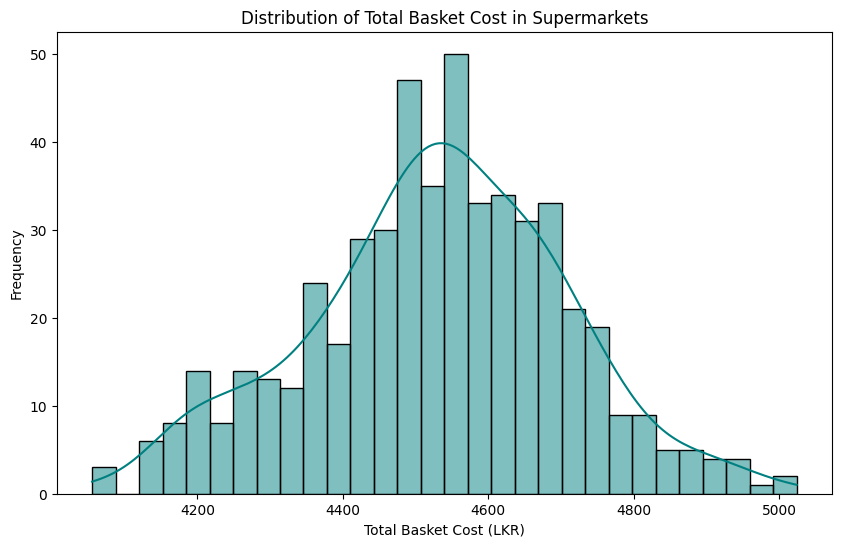

In [19]:
# Target Variable Distribution Analysis
plt.figure(figsize=(10, 6))
sns.histplot(data=cleaned_df, x='Total_Basket_Cost', bins=30, kde=True, color='teal')
plt.title("Distribution of Total Basket Cost in Supermarkets")
plt.xlabel("Total Basket Cost (LKR)")
plt.ylabel("Frequency")
plt.show()

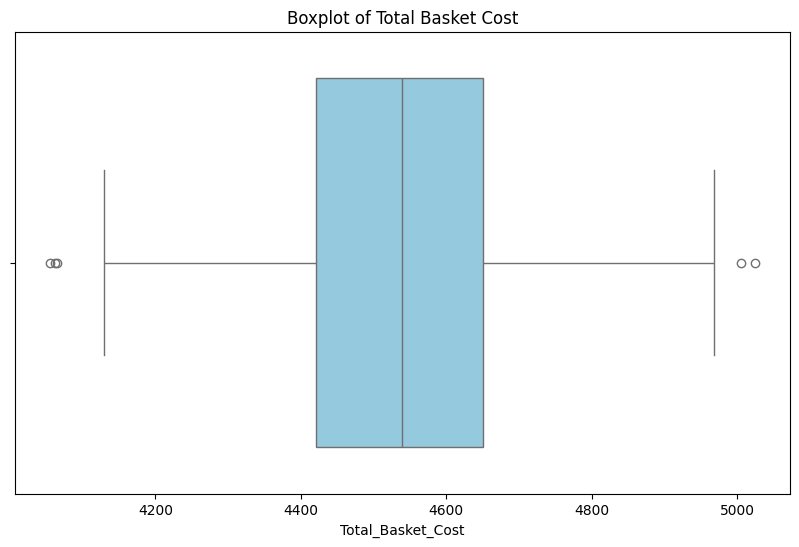

In [20]:
# Boxplot of Total Basket Cost
plt.figure(figsize=(10, 6))
sns.boxplot(data=cleaned_df['Total_Basket_Cost'], orient='h', color='skyblue')
plt.title("Boxplot of Total Basket Cost")
plt.show()

In [21]:
# Averages by Category
avg_cost = cleaned_df.groupby('Supermarket')['Total_Basket_Cost'].mean().sort_values()

print("\n--- Average Basket Cost per Supermarket ---")
print(avg_cost)


--- Average Basket Cost per Supermarket ---
Supermarket
Cargills Food City    4502.889428
Glomark               4504.731765
Sathosa               4513.419746
Spar                  4526.862980
Arpico Supercentre    4527.036192
Laughs Super          4554.706740
Keells                4562.186090
Name: Total_Basket_Cost, dtype: float64


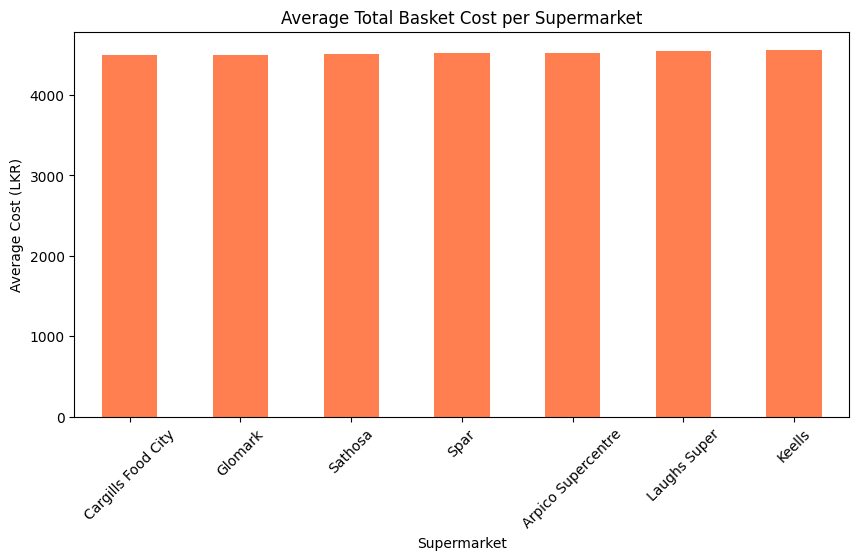

In [22]:
avg_cost.plot(kind='bar', figsize=(10, 5), color='coral')
plt.title("Average Total Basket Cost per Supermarket")
plt.ylabel("Average Cost (LKR)")
plt.xlabel("Supermarket")
plt.xticks(rotation=45)
plt.show()

In [24]:
# Supermarket-wise Data Balance
print("\n--- Record Count per Supermarket ---")
print(cleaned_df["Supermarket"].value_counts())


--- Record Count per Supermarket ---
Supermarket
Laughs Super          88
Keells                83
Glomark               75
Spar                  75
Arpico Supercentre    74
Cargills Food City    65
Sathosa               60
Name: count, dtype: int64


/tmp/ipykernel_283/3880084601.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_df, x='Supermarket', order=cleaned_df['Supermarket'].value_counts().index, palette='viridis')


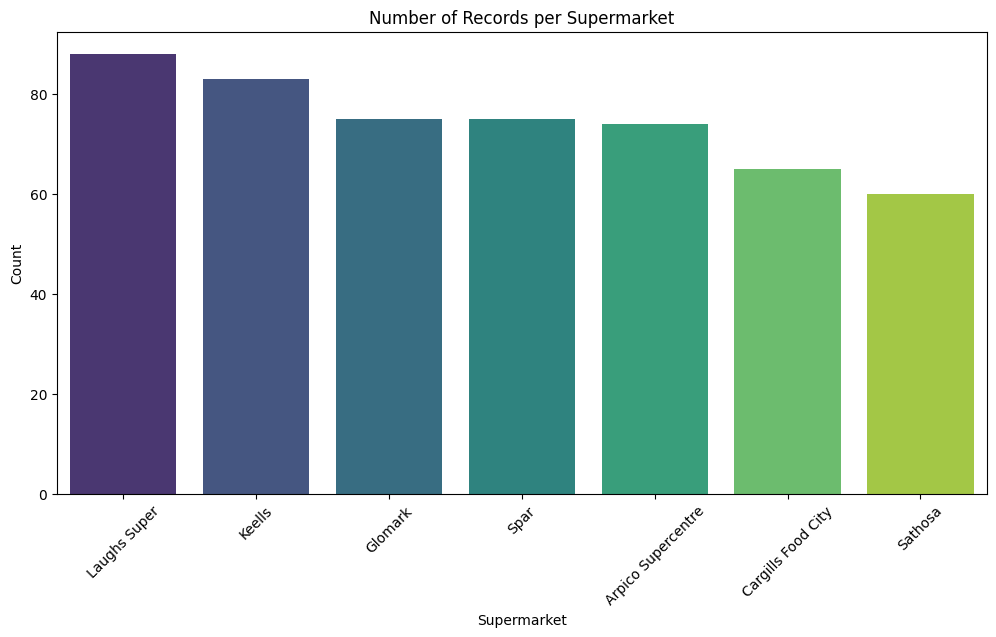

In [25]:
plt.figure(figsize=(12, 6))
sns.countplot(data=cleaned_df, x='Supermarket', order=cleaned_df['Supermarket'].value_counts().index, palette='viridis')
plt.xticks(rotation=45)
plt.xlabel("Supermarket")
plt.ylabel("Count")
plt.title("Number of Records per Supermarket")
plt.show()

<Figure size 1200x600 with 0 Axes>

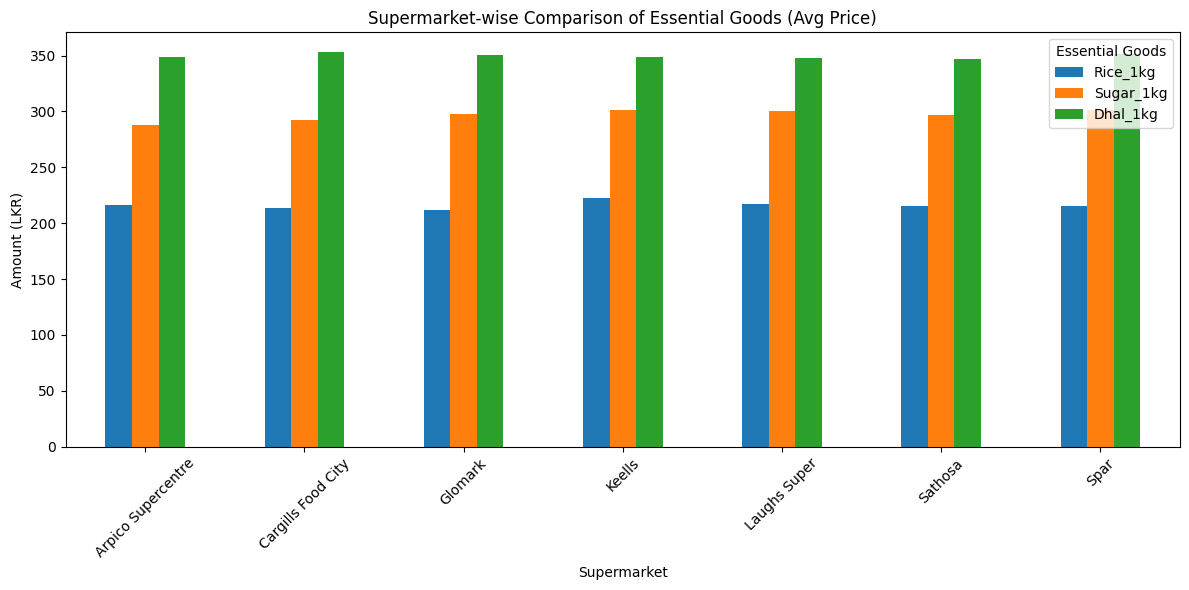

In [26]:
# Item-wise Comparison of Specific Goods
compare_cols = ['Rice_1kg', 'Sugar_1kg', 'Dhal_1kg']
market_stats = cleaned_df.groupby('Supermarket')[compare_cols].mean()

plt.figure(figsize=(12, 6))
market_stats.plot(kind='bar', stacked=False, figsize=(12,6))
plt.title('Supermarket-wise Comparison of Essential Goods (Avg Price)')
plt.ylabel('Amount (LKR)')
plt.xticks(rotation=45)
plt.legend(title='Essential Goods')
plt.tight_layout()
plt.show()

In [27]:
# 6. PRINCIPLE COMPONENT ANALYSIS (PCA)
# Select relevant item variables (excluding categorical and the target variable)
item_cols = ['Rice_1kg', 'Sugar_1kg', 'Dhal_1kg', 'Milk_Powder_400g', 'Eggs_10', 'Chicken_1kg', 'Vegetable_Assortment']
item_df = cleaned_df[item_cols]

# Standardize the data (important for PCA)
scaler = StandardScaler()
item_scaled = scaler.fit_transform(item_df)

# Perform PCA
pca = PCA()
principal_components = pca.fit_transform(item_scaled)

In [30]:
# Eigenvalues (explained variance)
eigenvalues = pca.explained_variance_
print("\n--- Eigenvalues (Explained Variance) ---")
print(eigenvalues)

total_variation = sum(eigenvalues)
print(f"\nTotal Variation: {total_variation:.4f}")


--- Eigenvalues (Explained Variance) ---
[1.34244644 1.11265573 1.10000387 0.97345314 0.9445161  0.89359626
 0.64681593]

Total Variation: 7.0135


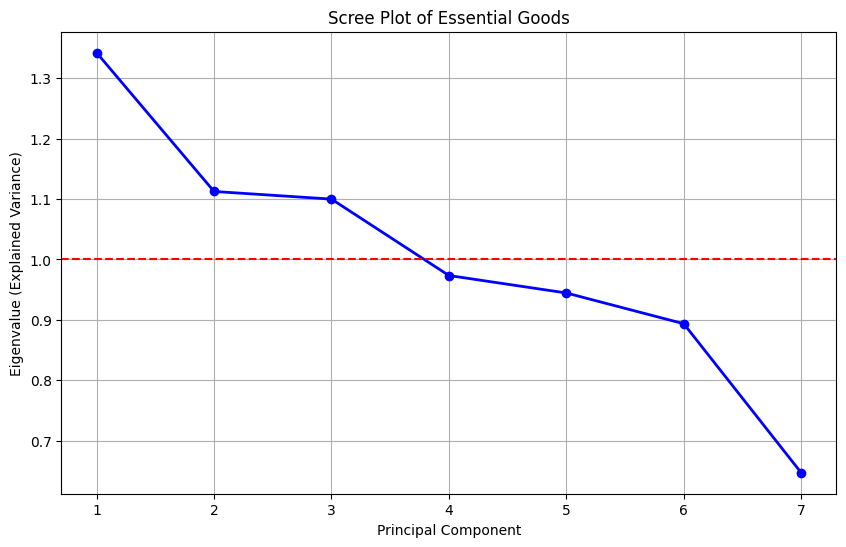

In [31]:
# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'bo-', linewidth=2)
plt.title('Scree Plot of Essential Goods')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Explained Variance)')
plt.axhline(y=1, color='r', linestyle='--')  # Kaiser criterion line
plt.grid()
plt.show()

In [33]:
# Cumulative proportion
proportions = eigenvalues / total_variation
cumulative_prop = np.cumsum(proportions)
print("\nCumulative Proportion of Total Variation:")
for i, cum_prop in enumerate(cumulative_prop):
    print(f"PC1 to PC{i+1}: {cum_prop:.4f} ({cum_prop*100:.2f}%)")


Cumulative Proportion of Total Variation:
PC1 to PC1: 0.1914 (19.14%)
PC1 to PC2: 0.3501 (35.01%)
PC1 to PC3: 0.5069 (50.69%)
PC1 to PC4: 0.6457 (64.57%)
PC1 to PC5: 0.7804 (78.04%)
PC1 to PC6: 0.9078 (90.78%)
PC1 to PC7: 1.0000 (100.00%)


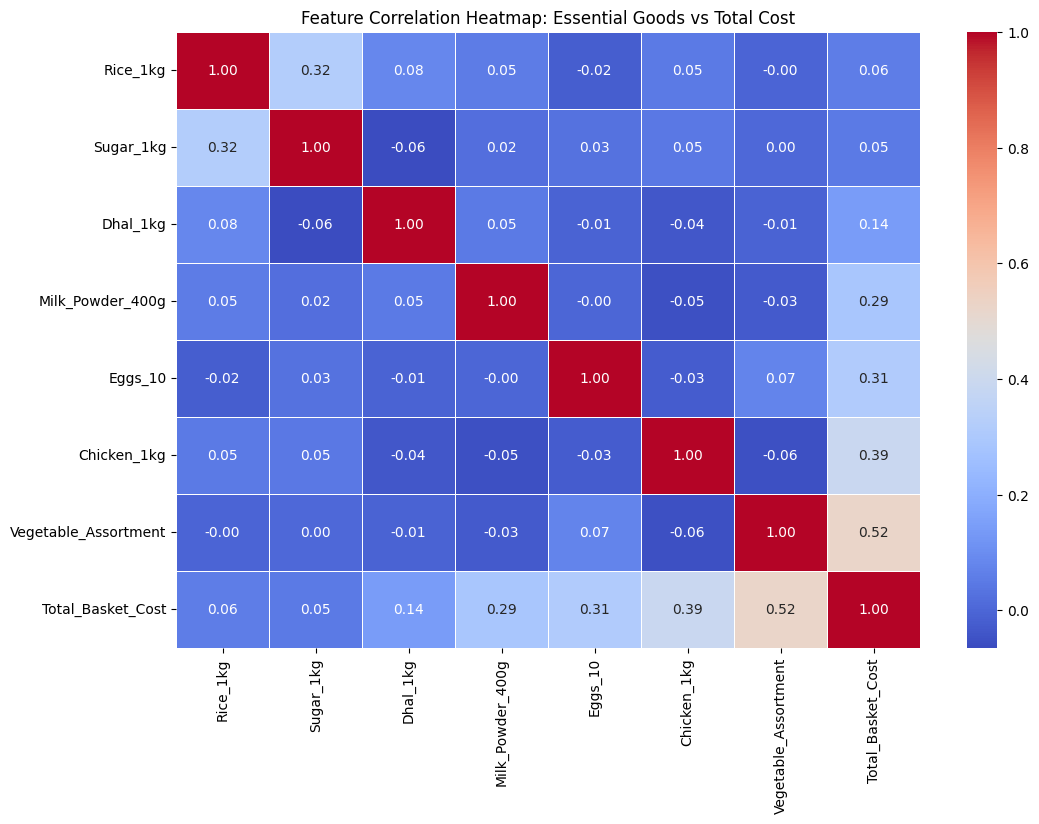

In [35]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cleaned_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap: Essential Goods vs Total Cost")
plt.show()

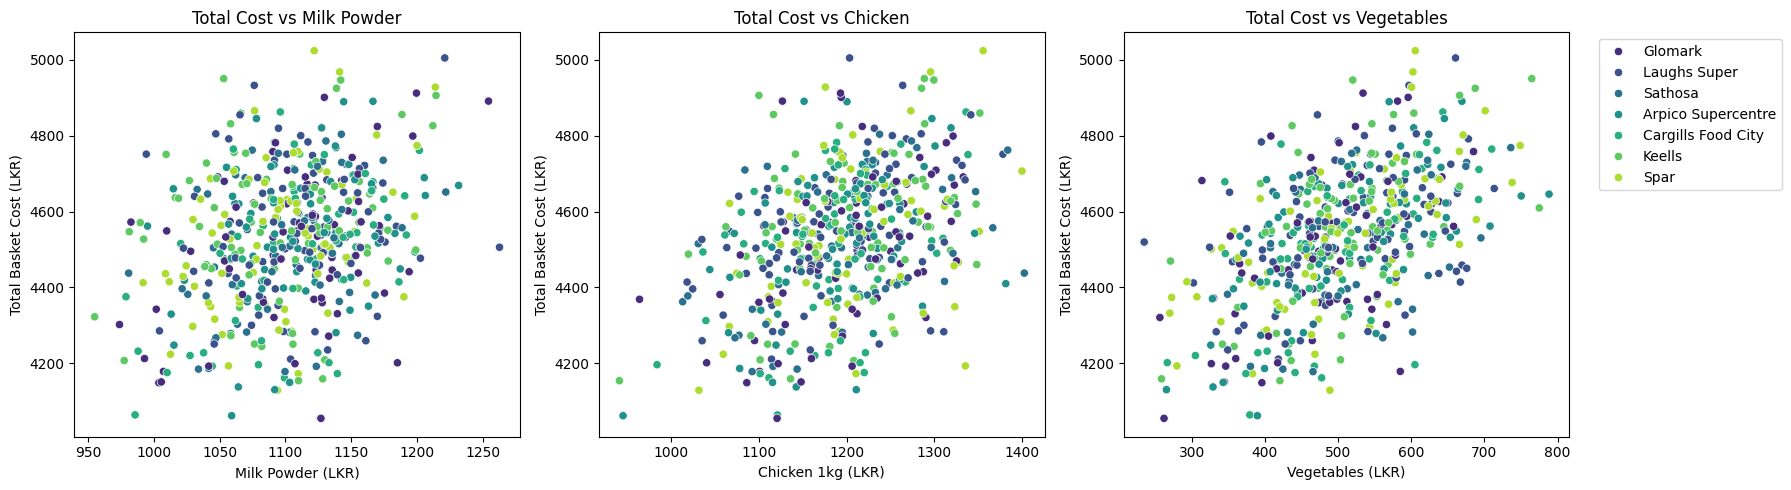

In [37]:
# Scatter Plots
plt.figure(figsize=(18, 5))

# Plot 1: Cost vs Milk Powder
plt.subplot(1, 3, 1)
sns.scatterplot(x='Milk_Powder_400g', y='Total_Basket_Cost', data=cleaned_df, hue='Supermarket', palette='viridis', legend=False)
plt.title('Total Cost vs Milk Powder')
plt.xlabel('Milk Powder (LKR)')
plt.ylabel('Total Basket Cost (LKR)')

# Plot 2: Cost vs Chicken
plt.subplot(1, 3, 2)
sns.scatterplot(x='Chicken_1kg', y='Total_Basket_Cost', data=cleaned_df, hue='Supermarket', palette='viridis', legend=False)
plt.title('Total Cost vs Chicken')
plt.xlabel('Chicken 1kg (LKR)')
plt.ylabel('Total Basket Cost (LKR)')

# Plot 3: Cost vs Vegetables
plt.subplot(1, 3, 3)
sns.scatterplot(x='Vegetable_Assortment', y='Total_Basket_Cost', data=cleaned_df, hue='Supermarket', palette='viridis')
plt.title('Total Cost vs Vegetables')
plt.xlabel('Vegetables (LKR)')
plt.ylabel('Total Basket Cost (LKR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [38]:
# AI/ML METHODS
# Define Features and Target - We use the individual item prices to predict the total basket cost
features = ['Rice_1kg', 'Sugar_1kg', 'Dhal_1kg', 'Milk_Powder_400g', 'Eggs_10', 'Chicken_1kg', 'Vegetable_Assortment']
X = cleaned_df[features]
y = cleaned_df['Total_Basket_Cost']

# Train-Test Split
# 70% of data for training the AI, 30% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=88)

In [40]:
# Model 1: Linear Regression
print("--- Linear Regression Performance ---")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, lr_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, lr_pred):.4f}")
print(f"R2 Score: {r2_score(y_test, lr_pred):.4f}\n")

--- Linear Regression Performance ---
MAE: 87.9500
MSE: 10820.5148
R2 Score: 0.7151



In [41]:
# Model 2: Random Forest Regressor
print("--- Random Forest Performance ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=88)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, rf_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, rf_pred):.4f}")
print(f"R2 Score: {r2_score(y_test, rf_pred):.4f}\n")

--- Random Forest Performance ---
MAE: 97.6407
MSE: 15010.8724
R2 Score: 0.6048



In [42]:
# Model 3: Deep Neural Network
print("--- Neural Network Performance ---")

import random
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout

# Lock all random seeds for complete reproducibility
np.random.seed(88)
random.seed(88)
tf.random.set_seed(88)

# Scaling data is highly recommended for Neural Networks to prevent exploding gradients
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)

# Building the sequential model using modern Keras syntax
nn_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') # Output layer for regression
])

# Compile the model
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model (silently with verbose=0 to keep the output clean)
history = nn_model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_data=(X_test_scaled, y_test), verbose=0)

# Make predictions
nn_pred = nn_model.predict(X_test_scaled).flatten()

print(f"MAE: {mean_absolute_error(y_test, nn_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, nn_pred):.4f}")
print(f"R2 Score: {r2_score(y_test, nn_pred):.4f}")

--- Neural Network Performance ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
MAE: 135.5284
MSE: 30954.5103
R2 Score: 0.1851
